<a href="https://colab.research.google.com/github/rubenzito/localidadespalhmento/blob/main/Medidas_de_Localidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medidas de localidade em dados industriais com o **AI4I 2020 Predictive Maintenance Dataset**

Neste notebook Colab vamos ilustrar, com uma base de **manutenção preditiva industrial**, as diferenças práticas entre **moda, média, mediana, quantis e percentis**.

## Base utilizada
Usaremos o **AI4I 2020 Predictive Maintenance Dataset**, que está disponível no **Kaggle** e também é descrito no **UCI Machine Learning Repository**.  
Para facilitar a execução no Colab, o notebook baixa automaticamente um **espelho público do mesmo CSV**.

## Ideia do exemplo
Em vez de apresentar apenas fórmulas, vamos responder perguntas práticas, como:

- Qual é o **valor típico** de torque e desgaste de ferramenta?
- Quando a **média** e a **mediana** contam histórias diferentes?
- Como usar **quantis** e **percentis** para definir faixas operacionais?
- Qual é a **categoria mais frequente** de produto?

> Contexto industrial: a base representa medições de processo e variáveis associadas à falha de máquina, o que torna a discussão útil para manufatura, manutenção e monitoramento operacional.

In [ ]:
# =========================
# 1. Importação e download
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Espelho público do CSV do dataset AI4I 2020
csv_url = "https://raw.githubusercontent.com/SamyamoyRakshit/AI4I-2020-Predictive-Maintenance-Dataset__Linear-Regression/main/ai4i2020.csv"

# Leitura da base
df = pd.read_csv(csv_url)

print("Dimensão da base:", df.shape)
display(df.head())

Dimensão da base: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1) Conhecendo as variáveis

Antes de calcular medidas de localidade, precisamos entender **o que cada variável mede**.  
Nesta base, algumas colunas especialmente úteis para o nosso objetivo são:

- **Air temperature [K]**: temperatura do ar;
- **Process temperature [K]**: temperatura do processo;
- **Rotational speed [rpm]**: rotação;
- **Torque [Nm]**: torque;
- **Tool wear [min]**: desgaste da ferramenta;
- **Type**: tipo do produto (`L`, `M`, `H`).

As variáveis numéricas serão usadas para **média, mediana, quantis e percentis**.  
A variável categórica `Type` será usada para discutir a **moda**.

In [ ]:
# ====================================
# 2. Ajustes simples para a análise
# ====================================

# Renomeando colunas para nomes mais curtos
df2 = df.rename(columns={
    "Air temperature [K]": "air_temp_k",
    "Process temperature [K]": "process_temp_k",
    "Rotational speed [rpm]": "rot_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "machine_failure",
    "Product ID": "product_id",
    "Type": "type"
})

# Seleção de variáveis para o estudo
vars_numericas = ["air_temp_k", "process_temp_k", "rot_speed_rpm", "torque_nm", "tool_wear_min"]

print("Tipos de dados:")
display(df2[vars_numericas + ["type", "machine_failure"]].dtypes)

print("\nResumo estatístico inicial:")
display(df2[vars_numericas].describe().T)

Tipos de dados:


,0
air_temp_k,float64
process_temp_k,float64
rot_speed_rpm,int64
torque_nm,float64
tool_wear_min,int64
type,object
machine_failure,int64



Resumo estatístico inicial:


,count,mean,std,min,25%,50%,75%,max
air_temp_k,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temp_k,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rot_speed_rpm,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque_nm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear_min,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


## 2) Média, mediana e moda: o que cada medida resume?

As três medidas procuram representar um **valor central**, mas não da mesma forma:

- **Média**: soma dos valores dividida pelo número de observações.  
  É muito útil, mas pode ser puxada por valores extremos.
- **Mediana**: valor central da distribuição ordenada.  
  É mais robusta a assimetrias e outliers.
- **Moda**: valor mais frequente.  
  É especialmente natural para variáveis categóricas, mas também pode ser calculada em variáveis discretas.

Em contexto industrial:
- a **média** pode representar a condição média de operação;
- a **mediana** pode representar a condição “mais típica” quando há assimetria;
- a **moda** pode representar o regime/categoria mais frequente.

In [ ]:
# ===========================================
# 3. Cálculo de média, mediana e moda
# ===========================================

def resumo_localidade(serie):
    moda = serie.mode()
    return pd.Series({
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": moda.iloc[0] if len(moda) > 0 else np.nan,
        "desvio_padrao": serie.std(),
        "assimetria": serie.skew()
    })

tabela_localidade = df2[vars_numericas].apply(resumo_localidade).T
display(tabela_localidade.round(3))

print("Moda da variável categórica 'type':")
display(df2["type"].mode())

print("\nDistribuição de frequência de 'type':")
display(df2["type"].value_counts())

,media,mediana,moda,desvio_padrao,assimetria
air_temp_k,300.005,300.1,300.7,2.000,0.114
process_temp_k,310.006,310.1,310.6,1.484,0.015
rot_speed_rpm,1538.776,1503.0,1452.0,179.284,1.993
torque_nm,39.987,40.1,40.2,9.969,-0.010
tool_wear_min,107.951,108.0,0.0,63.654,0.027


Moda da variável categórica 'type':


,type
0,L



Distribuição de frequência de 'type':


,count
type,
L,6000
M,2997
H,1003


## 3) Como interpretar as diferenças entre média e mediana?

Quando **média** e **mediana** ficam muito próximas, a distribuição tende a ser relativamente simétrica.  
Quando a **média** fica claramente acima ou abaixo da **mediana**, isso sugere assimetria.

Nesta base, duas variáveis são didaticamente interessantes:

- **`torque_nm`**: costuma ter comportamento mais concentrado;
- **`tool_wear_min`**: tende a mostrar uma dispersão maior e uma interpretação muito útil com quantis.

Nos gráficos abaixo, traçaremos:
- linha da **média**,
- linha da **mediana**,
- linha da **moda**.

Assim, fica visível quando essas medidas praticamente coincidem e quando se afastam.

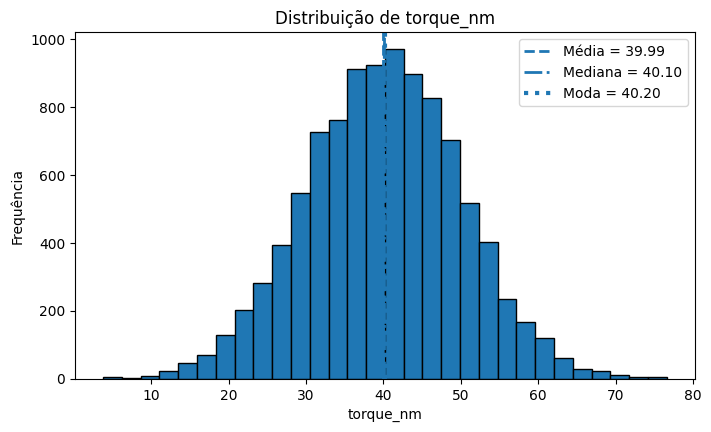

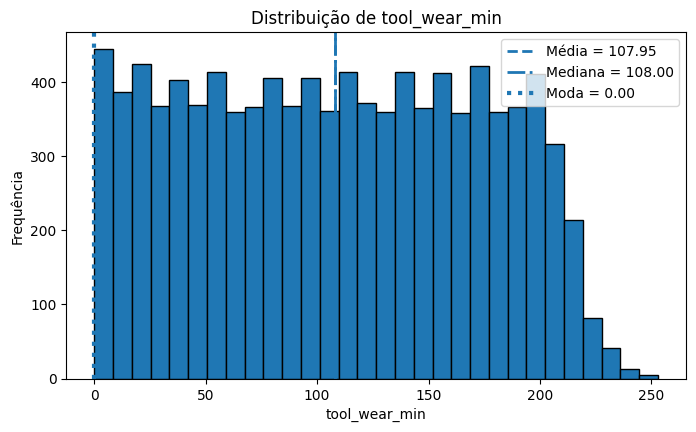

In [ ]:
# ==================================================
# 4. Visualização: média vs mediana vs moda
# ==================================================

def plot_medidas_localidade(df, coluna, bins=30):
    s = df[coluna].dropna()
    media = s.mean()
    mediana = s.median()
    moda = s.mode().iloc[0]

    plt.figure(figsize=(8, 4.5))
    plt.hist(s, bins=bins, edgecolor="black")
    plt.axvline(media, linestyle="--", linewidth=2, label=f"Média = {media:.2f}")
    plt.axvline(mediana, linestyle="-.", linewidth=2, label=f"Mediana = {mediana:.2f}")
    plt.axvline(moda, linestyle=":", linewidth=3, label=f"Moda = {moda:.2f}")
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

plot_medidas_localidade(df2, "torque_nm")
plot_medidas_localidade(df2, "tool_wear_min")

## 4) Quantis e percentis: dividindo a operação em faixas

Os **quantis** e **percentis** não resumem apenas um centro: eles ajudam a **posicionar** observações dentro da distribuição.

### Quantis
- **Q1 (25%)**: 25% dos valores estão abaixo dele;
- **Q2 (50%)**: é a própria **mediana**;
- **Q3 (75%)**: 75% dos valores estão abaixo dele.

### Percentis
São a mesma ideia, mas com uma escala mais fina:
- **P10**: 10% abaixo;
- **P50**: igual à mediana;
- **P90**: 90% abaixo.

### Uso prático na indústria
Essas medidas são úteis para:
- definir **faixas operacionais normais**;
- identificar valores em **regime elevado** ou **regime crítico**;
- construir regras simples de monitoramento, por exemplo:
  - desgaste acima do **percentil 90**;
  - torque abaixo do **percentil 10**;
  - rotação entre o **Q1** e o **Q3**.

In [ ]:
# ===========================================
# 5. Quantis e percentis
# ===========================================

quantis = df2[vars_numericas].quantile([0.25, 0.50, 0.75]).T
quantis.columns = ["Q1_25%", "Q2_50%_mediana", "Q3_75%"]

percentis = df2[vars_numericas].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentis.columns = ["P10", "P25", "P50", "P75", "P90"]

print("Quantis principais:")
display(quantis.round(3))

print("Percentis selecionados:")
display(percentis.round(3))

Quantis principais:


,Q1_25%,Q2_50%_mediana,Q3_75%
air_temp_k,298.3,300.1,301.5
process_temp_k,308.8,310.1,311.1
rot_speed_rpm,1423.0,1503.0,1612.0
torque_nm,33.2,40.1,46.8
tool_wear_min,53.0,108.0,162.0


Percentis selecionados:


,P10,P25,P50,P75,P90
air_temp_k,297.4,298.3,300.1,301.5,302.7
process_temp_k,308.1,308.8,310.1,311.1,311.9
rot_speed_rpm,1364.0,1423.0,1503.0,1612.0,1746.0
torque_nm,27.2,33.2,40.1,46.8,52.6
tool_wear_min,20.0,53.0,108.0,162.0,195.0


## 5) Exemplo prático: classificando desgaste da ferramenta por percentis

Uma aplicação intuitiva de percentis é transformar uma variável contínua em **faixas de interpretação operacional**.

Aqui vamos usar `tool_wear_min`:

- até o **P25**: desgaste baixo;
- entre **P25** e **P75**: desgaste típico/intermediário;
- acima do **P75**: desgaste alto;
- acima do **P90**: desgaste muito alto.

Essa ideia é útil porque não depende apenas de “achismo” ou de um limite arbitrário; ela usa a própria distribuição observada na base.

In [ ]:
# ======================================================
# 6. Criando faixas operacionais com base em percentis
# ======================================================

p25 = df2["tool_wear_min"].quantile(0.25)
p75 = df2["tool_wear_min"].quantile(0.75)
p90 = df2["tool_wear_min"].quantile(0.90)

def classificar_desgaste(x):
    if x <= p25:
        return "baixo"
    elif x <= p75:
        return "intermediario"
    elif x <= p90:
        return "alto"
    else:
        return "muito_alto"

df2["tool_wear_class"] = df2["tool_wear_min"].apply(classificar_desgaste)

print("Limites usados:")
print(f"P25 = {p25:.2f}")
print(f"P75 = {p75:.2f}")
print(f"P90 = {p90:.2f}")

print("\nFrequência por faixa:")
display(df2["tool_wear_class"].value_counts())

print("\nFalha média por faixa de desgaste:")
display(df2.groupby("tool_wear_class")["machine_failure"].mean().sort_index())

Limites usados:
P25 = 53.00
P75 = 162.00
P90 = 195.00

Frequência por faixa:


,count
tool_wear_class,
intermediario,4975
baixo,2529
alto,1505
muito_alto,991



Falha média por faixa de desgaste:


,machine_failure
tool_wear_class,
alto,0.029900
baixo,0.021748
intermediario,0.022312
muito_alto,0.129162


## 6) Moda em variável categórica: qual tipo de produto é o mais comum?

A **moda** é a medida de localidade mais natural para dados categóricos.

Na variável `type`, a moda responde:
> **Qual tipo de produto aparece com maior frequência na operação?**

Esse tipo de informação é útil porque:
- ajuda a entender o **perfil predominante** da produção;
- contextualiza análises posteriores;
- evita interpretar médias numéricas sem considerar a composição do mix produtivo.

In [ ]:
# ===========================================
# 7. Moda categórica e comparação por tipo
# ===========================================

moda_type = df2["type"].mode().iloc[0]
print("Moda de 'type':", moda_type)

freq_type = df2["type"].value_counts(normalize=True).mul(100).round(2).rename("percentual")
display(freq_type.to_frame())

print("\nMédias das variáveis numéricas por tipo de produto:")
display(df2.groupby("type")[vars_numericas].mean().round(2))

Moda de 'type': L


,percentual
type,
L,60.00
M,29.97
H,10.03



Médias das variáveis numéricas por tipo de produto:


,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min
type,,,,,
H,299.87,309.93,1538.15,39.84,107.42
L,300.02,310.01,1539.47,40.00,108.38
M,300.03,310.02,1537.60,40.02,107.27


## 7) Síntese conceitual

Com este exemplo industrial, podemos resumir assim:

- **Média**: boa para resumir o nível médio de operação, mas sensível a extremos;
- **Mediana**: melhor candidata a “valor típico” quando a distribuição é assimétrica;
- **Moda**: melhor resumo para categorias e também útil em variáveis discretas;
- **Quantis**: particionam a distribuição em blocos;
- **Percentis**: refinam essa ideia e ajudam a construir faixas e alarmes operacionais.

Em problemas industriais, essas medidas são úteis não apenas para descrição, mas também para:
- monitoramento,
- definição de limites,
- segmentação operacional,
- criação de regras simples de negócio e manutenção.

In [ ]:
# ===========================================
# 8. Tabela final-resumo
# ===========================================

resumo_final = pd.DataFrame({
    "media": df2[vars_numericas].mean(),
    "mediana": df2[vars_numericas].median(),
    "q1": df2[vars_numericas].quantile(0.25),
    "q3": df2[vars_numericas].quantile(0.75),
    "p10": df2[vars_numericas].quantile(0.10),
    "p90": df2[vars_numericas].quantile(0.90),
})

display(resumo_final.round(3))

moda = df2["type"].mode().iloc[0]
display(Markdown(
    f'''
**Conclusões rápidas do exemplo**
- A moda de `type` é **{moda}**.
- A mediana coincide com o percentil 50, como esperado.
- As faixas baseadas em percentis permitem traduzir medições contínuas em classes operacionais interpretáveis.
'''
))

,media,mediana,q1,q3,p10,p90
air_temp_k,300.005,300.1,298.3,301.5,297.4,302.7
process_temp_k,310.006,310.1,308.8,311.1,308.1,311.9
rot_speed_rpm,1538.776,1503.0,1423.0,1612.0,1364.0,1746.0
torque_nm,39.987,40.1,33.2,46.8,27.2,52.6
tool_wear_min,107.951,108.0,53.0,162.0,20.0,195.0



**Conclusões rápidas do exemplo**
- A moda de `type` é **L**.
- A mediana coincide com o percentil 50, como esperado.
- As faixas baseadas em percentis permitem traduzir medições contínuas em classes operacionais interpretáveis.
